# ETF Valuation & Momentum Monitor
- 차트 1: 멀티플 Z-Score vs 모멘텀 스코어
- 차트 2: 멀티플 Z-Score vs 자금유입강도

각 ETF의 현재 위치와 1주일 전 위치를 화살표로 연결하여 표시

## 1. 파일 업로드

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import requests
import io
import os
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Colab)
!apt-get install -y fonts-nanum > /dev/null 2>&1

# 폰트 캐시 재생성
font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
for font in font_list:
    if 'Nanum' in font:
        fm.fontManager.addfont(font)

plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False
print("한글 폰트 설정 완료")

# 파일 경로 설정 (Colab 파일 시스템)
DATA_DIR = '/content/'  # Colab 기본 경로

print(f"\n파일 경로: {DATA_DIR}")
print("아래 9개 파일을 Colab 파일 탭에 업로드해주세요:")
print("  1. 1_pe_now.txt")
print("  2. 2_pe_1w.txt")
print("  3. 3_return.txt")
print("  4. 4_flow.txt")
print("  5. 5_pbr_now.txt")
print("  6. 6_pbr_1w.txt")
print("  7. 7_theme.txt")
print("  8. 8_psr_now.txt")
print("  9. 9_psr_1w.txt")

# 현재 업로드된 파일 목록
print("\n현재 업로드된 파일:")
for f in os.listdir(DATA_DIR):
    if f.endswith('.txt'):
        print(f"  - {f}")

## 2. 설정

In [ ]:
# ============================================================
# 밸류에이션 설정
# ============================================================

# PBR로 처리할 ETF 리스트 (명시적 지정)
PBR_ETF_LIST = ['BLOK-US', 'SOXX-US', 'BKCH-US']

# PSR로 처리할 ETF 리스트 (명시적 지정)
PSR_ETF_LIST = ['LIT-US', 'BATT-US']

# 음수 PER 감지 시 기본 대체 밸류에이션 ('PSR' 또는 'PBR')
DEFAULT_ALTERNATIVE = 'PSR'

# 음수 PER 판정 기준 (조정 가능)
NEGATIVE_PE_RULES = {
    'recent_days': 22,       # 최근 1개월 (영업일 기준)
    'historical_days': 750,  # 최근 3년 (영업일 기준)
    'recent_threshold': 1,   # 최근 1개월 내 음수 N건 이상이면 대체
    'historical_pct': 0.05,  # 최근 3년 내 음수 비율 N% 이상이면 대체
}

# ============================================================
# 텔레그램 설정
# ============================================================
BOT_TOKEN = "8328122559:AAEXkzJnxtljMON_Obt4uyb5PzJvx5-IS64"
CHAT_ID = "7481149685"

import os
os.environ['TELEGRAM_BOT_TOKEN'] = BOT_TOKEN
os.environ['TELEGRAM_CHAT_ID'] = CHAT_ID

# 설정 출력
print("=== 밸류에이션 설정 ===")
print(f"PBR 기준 ETF (명시적): {PBR_ETF_LIST}")
print(f"PSR 기준 ETF (명시적): {PSR_ETF_LIST}")
print(f"음수 PER 대체 기준: {DEFAULT_ALTERNATIVE}")
print(f"\n음수 PER 판정 규칙:")
print(f"  - 최근 {NEGATIVE_PE_RULES['recent_days']}일 내 음수 {NEGATIVE_PE_RULES['recent_threshold']}건 이상 → 대체")
print(f"  - 최근 {NEGATIVE_PE_RULES['historical_days']}일 내 음수 {NEGATIVE_PE_RULES['historical_pct']*100:.0f}% 이상 → 대체")
print("\n텔레그램 설정 완료")

## 3. 데이터 로드 및 전처리

In [ ]:
def load_pe_data(filepath):
    """PER/PBR/PSR 데이터 로드 (컬럼=ETF, 행=날짜)"""
    print(f"  로딩: {os.path.basename(filepath)}...")
    df = pd.read_csv(filepath, sep='\t', index_col=0)
    df.index = pd.to_datetime(df.index, format='%m/%d/%Y')
    df = df.replace('#N/A', np.nan).replace('', np.nan)
    df = df.astype(float)
    print(f"    완료: {df.shape[0]}행 x {df.shape[1]}컬럼")
    return df

def load_return_data(filepath):
    """모멘텀 스코어 데이터 로드 (행=ETF, 컬럼=지표)"""
    print(f"  로딩: {os.path.basename(filepath)}...")
    df = pd.read_csv(filepath, sep='\t', index_col=0)
    df = df.replace('#N/A', np.nan).replace('', np.nan)
    for col in ['Score', 'Score_1W']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f"    완료: {df.shape[0]}행 x {df.shape[1]}컬럼")
    return df

def load_flow_data(filepath):
    """자금유입 데이터 로드 (행=ETF, 컬럼=지표)"""
    print(f"  로딩: {os.path.basename(filepath)}...")
    df = pd.read_csv(filepath, sep='\t', index_col=0, skiprows=[1])
    df = df.replace('#N/A', np.nan).replace('', np.nan)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f"    완료: {df.shape[0]}행 x {df.shape[1]}컬럼")
    return df

def load_theme_data(filepath):
    """테마 정의 로드 (테마명 -> ETF 리스트)"""
    print(f"  로딩: {os.path.basename(filepath)}...")
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()
    lines = content.strip().split('\n')

    themes = {}
    for line in lines:
        parts = [p.strip() for p in line.split('\t')]
        theme_name = parts[0]
        # ETF 이름에 -US 붙이기 (빈값 제외)
        etfs = [f"{p}-US" for p in parts[1:] if p]
        themes[theme_name] = etfs

    print(f"    완료: {len(themes)}개 테마")
    for theme, etfs in themes.items():
        print(f"      {theme}: {len(etfs)}개 ETF")
    return themes

def find_file(pattern, directory):
    """패턴이 포함된 파일 찾기"""
    for fname in os.listdir(directory):
        if pattern.lower() in fname.lower() and fname.endswith('.txt'):
            return os.path.join(directory, fname)
    return None

# 데이터 로드
print("데이터 로드 중...")
pe_now = load_pe_data(find_file('1_pe_now', DATA_DIR) or f'{DATA_DIR}1_pe_now.txt')
pe_1w = load_pe_data(find_file('2_pe_1w', DATA_DIR) or f'{DATA_DIR}2_pe_1w.txt')
return_df = load_return_data(find_file('3_return', DATA_DIR) or f'{DATA_DIR}3_return.txt')
flow_df = load_flow_data(find_file('4_flow', DATA_DIR) or f'{DATA_DIR}4_flow.txt')
pbr_now = load_pe_data(find_file('5_pbr_now', DATA_DIR) or f'{DATA_DIR}5_pbr_now.txt')
pbr_1w = load_pe_data(find_file('6_pbr_1w', DATA_DIR) or f'{DATA_DIR}6_pbr_1w.txt')

# PSR 데이터 로드
psr_now_file = find_file('8_psr_now', DATA_DIR)
psr_1w_file = find_file('9_psr_1w', DATA_DIR)

if psr_now_file and psr_1w_file:
    psr_now = load_pe_data(psr_now_file)
    psr_1w = load_pe_data(psr_1w_file)
else:
    print("  경고: PSR 파일이 없습니다. PSR 기능이 제한됩니다.")
    psr_now = pd.DataFrame()
    psr_1w = pd.DataFrame()

theme_file = find_file('theme', DATA_DIR)
if theme_file:
    themes = load_theme_data(theme_file)
else:
    print("경고: 테마 파일을 찾을 수 없습니다.")
    themes = {}

print("\n모든 파일 로드 완료!")

## 4. Z-Score 계산

In [ ]:
def calculate_zscore(df, exclude_latest=True):
    """
    5년치 데이터로 Z-Score 계산
    - exclude_latest=True: 최신값 제외하고 평균/표준편차 계산 (권장)
    - Z = (현재값 - 과거평균) / 과거표준편차
    """
    result = {}

    for etf in df.columns:
        series = df[etf].dropna()

        if len(series) < 10:  # 데이터가 너무 적으면 스킵
            result[etf] = np.nan
            continue

        # 날짜 기준 정렬 (최신이 맨 앞)
        series = series.sort_index(ascending=False)

        current_value = series.iloc[0]  # 최신값

        if exclude_latest:
            # 최신값 제외하고 평균/표준편차 계산
            historical = series.iloc[1:]
        else:
            historical = series

        mean = historical.mean()
        std = historical.std()

        if std == 0 or np.isnan(std):
            result[etf] = np.nan
        else:
            zscore = (current_value - mean) / std
            result[etf] = zscore

    return result


def check_negative_pe(pe_df, etf, rules):
    """
    음수 PER 판정: 최근 1개월 또는 3년 내 음수 비율 체크
    
    Returns:
        (is_negative, reason) - 대체 필요 여부와 이유
    """
    if etf not in pe_df.columns:
        return False, None
    
    series = pe_df[etf].dropna().sort_index(ascending=False)
    
    if len(series) == 0:
        return False, None
    
    # 최근 1개월 (recent_days) 체크
    recent_data = series.head(rules['recent_days'])
    recent_negative_count = (recent_data < 0).sum()
    
    if recent_negative_count >= rules['recent_threshold']:
        return True, f"최근 {rules['recent_days']}일 내 음수 {recent_negative_count}건"
    
    # 최근 3년 (historical_days) 체크
    historical_data = series.head(rules['historical_days'])
    if len(historical_data) > 0:
        historical_negative_pct = (historical_data < 0).sum() / len(historical_data)
        
        if historical_negative_pct >= rules['historical_pct']:
            return True, f"최근 {len(historical_data)}일 중 음수 {historical_negative_pct*100:.1f}%"
    
    return False, None


def determine_valuation_type(etf, pe_df, rules, default_alt, pbr_list, psr_list):
    """
    ETF의 밸류에이션 기준 결정
    
    우선순위:
    1. PBR_ETF_LIST에 명시 → PBR
    2. PSR_ETF_LIST에 명시 → PSR
    3. 음수 PER 감지 → DEFAULT_ALTERNATIVE
    4. 그 외 → PER
    
    Returns:
        (valuation_type, reason)
    """
    # 1순위: 명시적 PBR 리스트
    if etf in pbr_list:
        return 'PBR', '명시적 지정'
    
    # 1순위: 명시적 PSR 리스트
    if etf in psr_list:
        return 'PSR', '명시적 지정'
    
    # 2순위: 음수 PER 감지
    is_negative, reason = check_negative_pe(pe_df, etf, rules)
    if is_negative:
        return default_alt, f'PER 음수 감지 ({reason})'
    
    # 3순위: 기본 PER
    return 'PER', '-'


# ============================================================
# Z-Score 계산 및 밸류에이션 기준 결정
# ============================================================
print("Z-Score 계산 중...")

# 기본 Z-Score 계산 (모든 지표)
zscore_per_now = calculate_zscore(pe_now, exclude_latest=True)
zscore_per_1w = calculate_zscore(pe_1w, exclude_latest=True)

zscore_pbr_now = calculate_zscore(pbr_now, exclude_latest=True)
zscore_pbr_1w = calculate_zscore(pbr_1w, exclude_latest=True)

zscore_psr_now = calculate_zscore(psr_now, exclude_latest=True) if not psr_now.empty else {}
zscore_psr_1w = calculate_zscore(psr_1w, exclude_latest=True) if not psr_1w.empty else {}

# 최종 Z-Score 및 밸류에이션 기준 결정
zscore_now = {}
zscore_1w = {}
etf_valuation_info = {}  # ETF별 밸류에이션 정보 저장

all_etfs = set(pe_now.columns)

for etf in all_etfs:
    # 밸류에이션 기준 결정
    val_type, reason = determine_valuation_type(
        etf, pe_now, NEGATIVE_PE_RULES, DEFAULT_ALTERNATIVE, PBR_ETF_LIST, PSR_ETF_LIST
    )
    
    # Z-Score 선택
    if val_type == 'PBR':
        z_now = zscore_pbr_now.get(etf, np.nan)
        z_1w = zscore_pbr_1w.get(etf, np.nan)
    elif val_type == 'PSR':
        z_now = zscore_psr_now.get(etf, np.nan)
        z_1w = zscore_psr_1w.get(etf, np.nan)
    else:  # PER
        z_now = zscore_per_now.get(etf, np.nan)
        z_1w = zscore_per_1w.get(etf, np.nan)
    
    zscore_now[etf] = z_now
    zscore_1w[etf] = z_1w
    etf_valuation_info[etf] = {'type': val_type, 'reason': reason}

# 결과 출력
print("\n=== 밸류에이션 기준 요약 ===")
val_counts = {'PER': 0, 'PBR': 0, 'PSR': 0}
for etf, info in etf_valuation_info.items():
    val_counts[info['type']] += 1

print(f"PER 기준: {val_counts['PER']}개 ETF")
print(f"PBR 기준: {val_counts['PBR']}개 ETF")
print(f"PSR 기준: {val_counts['PSR']}개 ETF")

# PBR/PSR 사용 ETF 상세 출력
print("\n[PBR 사용 ETF]")
for etf, info in etf_valuation_info.items():
    if info['type'] == 'PBR':
        z = zscore_now.get(etf, np.nan)
        z_str = f"{z:.2f}" if not np.isnan(z) else "N/A"
        print(f"  {etf}: Z-Score={z_str} ({info['reason']})")

print("\n[PSR 사용 ETF]")
for etf, info in etf_valuation_info.items():
    if info['type'] == 'PSR':
        z = zscore_now.get(etf, np.nan)
        z_str = f"{z:.2f}" if not np.isnan(z) else "N/A"
        print(f"  {etf}: Z-Score={z_str} ({info['reason']})")

print(f"\nZ-Score 계산 완료: {len([v for v in zscore_now.values() if not np.isnan(v)])}개 ETF")

## 4-1. 밸류에이션 기준 요약 표

In [ ]:
# ============================================================
# 테마별 ETF 밸류에이션 기준 요약 표
# ============================================================

def create_valuation_summary_table(themes, etf_valuation_info, zscore_now):
    """
    테마별 ETF 밸류에이션 기준 요약 표 생성
    - 테마별, 밸류에이션 기준별로 정렬
    """
    rows = []
    
    for theme_name, etf_list in themes.items():
        for etf in etf_list:
            info = etf_valuation_info.get(etf, {'type': 'N/A', 'reason': 'N/A'})
            z_score = zscore_now.get(etf, np.nan)
            z_str = f"{z_score:.2f}" if not np.isnan(z_score) else "N/A"
            
            rows.append({
                '테마': theme_name,
                'ETF': etf.replace('-US', ''),
                '밸류에이션': info['type'],
                'Z-Score': z_str,
                '비고': info['reason']
            })
    
    df = pd.DataFrame(rows)
    
    # 정렬: 테마 → 밸류에이션 (PBR, PSR, PER 순)
    val_order = {'PBR': 0, 'PSR': 1, 'PER': 2, 'N/A': 3}
    df['_val_order'] = df['밸류에이션'].map(val_order)
    df = df.sort_values(['테마', '_val_order', 'ETF']).drop('_val_order', axis=1)
    df = df.reset_index(drop=True)
    
    return df


def print_valuation_summary(df_val):
    """밸류에이션 요약 표 출력 (테마별 그룹화)"""
    
    print("=" * 80)
    print("테마별 ETF 밸류에이션 기준 요약")
    print("=" * 80)
    print(f"{'테마':<20} {'ETF':<12} {'밸류에이션':<8} {'Z-Score':<10} {'비고'}")
    print("-" * 80)
    
    current_theme = None
    for _, row in df_val.iterrows():
        # 테마가 바뀌면 구분선
        if current_theme != row['테마']:
            if current_theme is not None:
                print("-" * 80)
            current_theme = row['테마']
        
        # 밸류에이션에 따라 강조
        val_marker = ""
        if row['밸류에이션'] == 'PBR':
            val_marker = "[PBR]"
        elif row['밸류에이션'] == 'PSR':
            val_marker = "[PSR]"
        else:
            val_marker = " PER "
        
        print(f"{row['테마']:<20} {row['ETF']:<12} {val_marker:<8} {row['Z-Score']:<10} {row['비고']}")
    
    print("=" * 80)


# 밸류에이션 요약 표 생성 및 출력
df_valuation_summary = create_valuation_summary_table(themes, etf_valuation_info, zscore_now)
print_valuation_summary(df_valuation_summary)

# 통계 요약
print("\n=== 밸류에이션 기준별 통계 ===")
val_stats = df_valuation_summary.groupby('밸류에이션').size()
for val_type in ['PER', 'PBR', 'PSR']:
    count = val_stats.get(val_type, 0)
    pct = count / len(df_valuation_summary) * 100
    print(f"  {val_type}: {count}개 ETF ({pct:.1f}%)")

# PBR/PSR 사용 ETF만 별도 표시
print("\n=== PBR/PSR 사용 ETF 목록 ===")
non_per = df_valuation_summary[df_valuation_summary['밸류에이션'] != 'PER']
if len(non_per) > 0:
    for _, row in non_per.iterrows():
        print(f"  [{row['밸류에이션']}] {row['테마']} - {row['ETF']}: {row['비고']}")
else:
    print("  (없음)")

# DataFrame 저장 (다른 셀에서 사용 가능)
print(f"\n* df_valuation_summary 변수에 전체 데이터 저장됨 ({len(df_valuation_summary)}개 ETF)")

## 5. 최종 데이터 통합

In [ ]:
# 테마별 데이터 집계
print("테마별 데이터 집계 중...")

theme_data = []

for theme_name, etf_list in themes.items():
    # 해당 테마의 ETF들만 필터링
    valid_etfs_zscore = [e for e in etf_list if e in zscore_now and not np.isnan(zscore_now.get(e, np.nan))]
    valid_etfs_momentum = [e for e in etf_list if e in return_df.index]
    valid_etfs_flow = [e for e in etf_list if e in flow_df.index]

    # Z-Score 평균 (현재 & 1주전)
    if valid_etfs_zscore:
        zscore_now_avg = np.nanmean([zscore_now[e] for e in valid_etfs_zscore])
        zscore_1w_avg = np.nanmean([zscore_1w.get(e, np.nan) for e in valid_etfs_zscore])
    else:
        zscore_now_avg = np.nan
        zscore_1w_avg = np.nan

    # 모멘텀 스코어 평균 (현재 & 1주전)
    if valid_etfs_momentum:
        momentum_now_avg = return_df.loc[valid_etfs_momentum, 'Score'].mean()
        momentum_1w_avg = return_df.loc[valid_etfs_momentum, 'Score_1W'].mean()
    else:
        momentum_now_avg = np.nan
        momentum_1w_avg = np.nan

    # Flow 계산: sum(WF-0W) / sum(AUM-1W) * 100 (%)
    if valid_etfs_flow:
        # 현재: WF-0W / AUM-1W
        wf_0w_sum = flow_df.loc[valid_etfs_flow, 'WF-0W'].sum()
        aum_1w_sum = flow_df.loc[valid_etfs_flow, 'AUM-1W'].sum()
        flow_now = (wf_0w_sum / aum_1w_sum * 100) if aum_1w_sum != 0 else np.nan

        # 1주전: WF-1W / AUM-2W
        wf_1w_sum = flow_df.loc[valid_etfs_flow, 'WF-1W'].sum()
        aum_2w_sum = flow_df.loc[valid_etfs_flow, 'AUM-2W'].sum()
        flow_1w = (wf_1w_sum / aum_2w_sum * 100) if aum_2w_sum != 0 else np.nan

        # 4주전: WF-4W / AUM-4W
        wf_4w_sum = flow_df.loc[valid_etfs_flow, 'flow_sum'].sum()
        aum_4w_sum = flow_df.loc[valid_etfs_flow, 'AUM-4W'].sum()
        flow_4w = (wf_4w_sum / aum_4w_sum * 100) if aum_4w_sum != 0 else np.nan

    else:
        wf_0w_sum = np.nan
        flow_now = np.nan
        flow_1w = np.nan

    theme_data.append({
        'Theme': theme_name,
        'ZScore_Now': zscore_now_avg,
        'ZScore_1W': zscore_1w_avg,
        'Momentum_Now': momentum_now_avg,
        'Momentum_1W': momentum_1w_avg,
        'Flow_Now': flow_now,
        'Flow_1W': flow_1w,
        'Flow_4W': flow_4w,
        'WF_Sum': wf_0w_sum,  # 순유입금액 ($M)
        'ETF_Count': len(etf_list)
    })

df_theme = pd.DataFrame(theme_data)
df_theme = df_theme.set_index('Theme')

# 유효한 데이터만 필터링 (차트별로)
df_chart1 = df_theme.dropna(subset=['ZScore_Now', 'ZScore_1W', 'Momentum_Now', 'Momentum_1W'])
df_chart2 = df_theme.dropna(subset=['ZScore_Now', 'ZScore_1W', 'Flow_Now', 'Flow_1W'])
df_chart3 = df_theme.dropna(subset=['WF_Sum', 'Flow_Now', 'Flow_4W'])  # 차트3용

print(f"\n차트1 (멀티플 vs 모멘텀): {len(df_chart1)}개 테마")
print(f"차트2 (멀티플 vs 플로우): {len(df_chart2)}개 테마")
print(f"차트3 (순유입 & 유입강도): {len(df_chart3)}개 테마")

# 데이터 미리보기
print("\n=== 테마별 데이터 ===")
print(df_theme.round(3))

테마별 데이터 집계 중...

차트1 (멀티플 vs 모멘텀): 28개 테마
차트2 (멀티플 vs 플로우): 28개 테마
차트3 (순유입 & 유입강도): 28개 테마

=== 테마별 데이터 ===
              ZScore_Now  ZScore_1W  Momentum_Now  Momentum_1W  Flow_Now  \
Theme                                                                      
클린에너지             -0.387     -0.425         1.046        1.210     0.002   
태양광               -0.246     -0.227         1.040        1.065     0.000   
풍력                -0.644     -0.706         1.244        1.183     0.000   
스마트그리드             0.124      0.210         0.963        1.134     1.552   
천연가스               1.290      1.268         0.849        0.980     0.000   
원자력                1.522      1.564         0.480        0.854     1.033   
인프라투자              0.742      0.752         0.752        0.853     0.379   
로보틱스/자동화          -0.085     -0.067         0.742        0.897     0.595   
2차전지               0.014      0.028         1.980        1.759     1.176   
전기차&자율주행           1.284      1.509         1.121      

## 6. 차트 생성

차트 저장: chart1_valuation_momentum.png


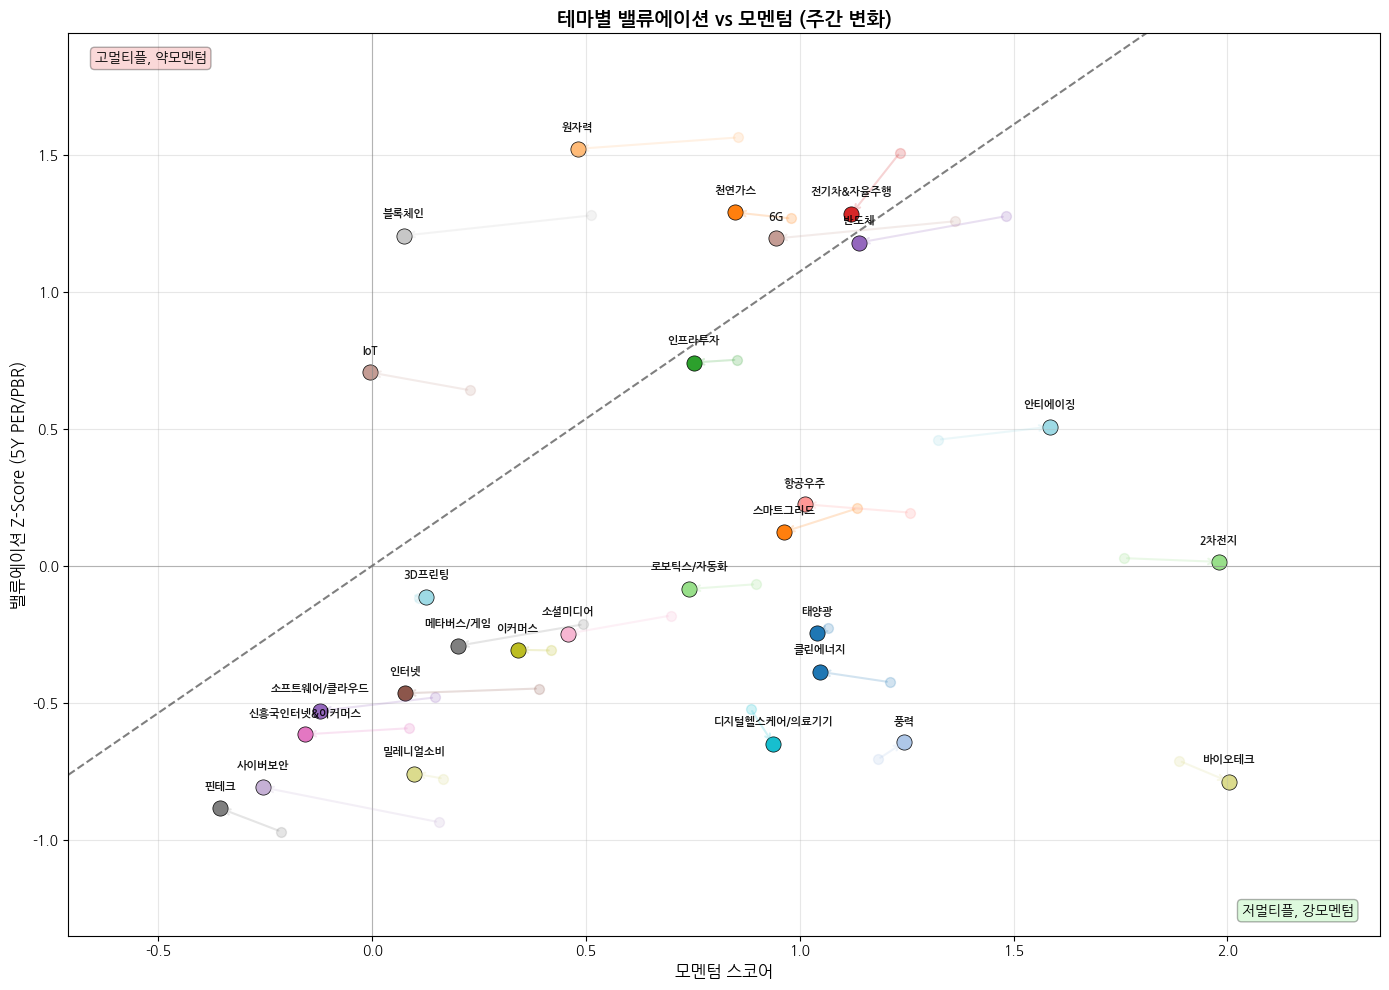

차트 저장: chart3_flow_bar.png


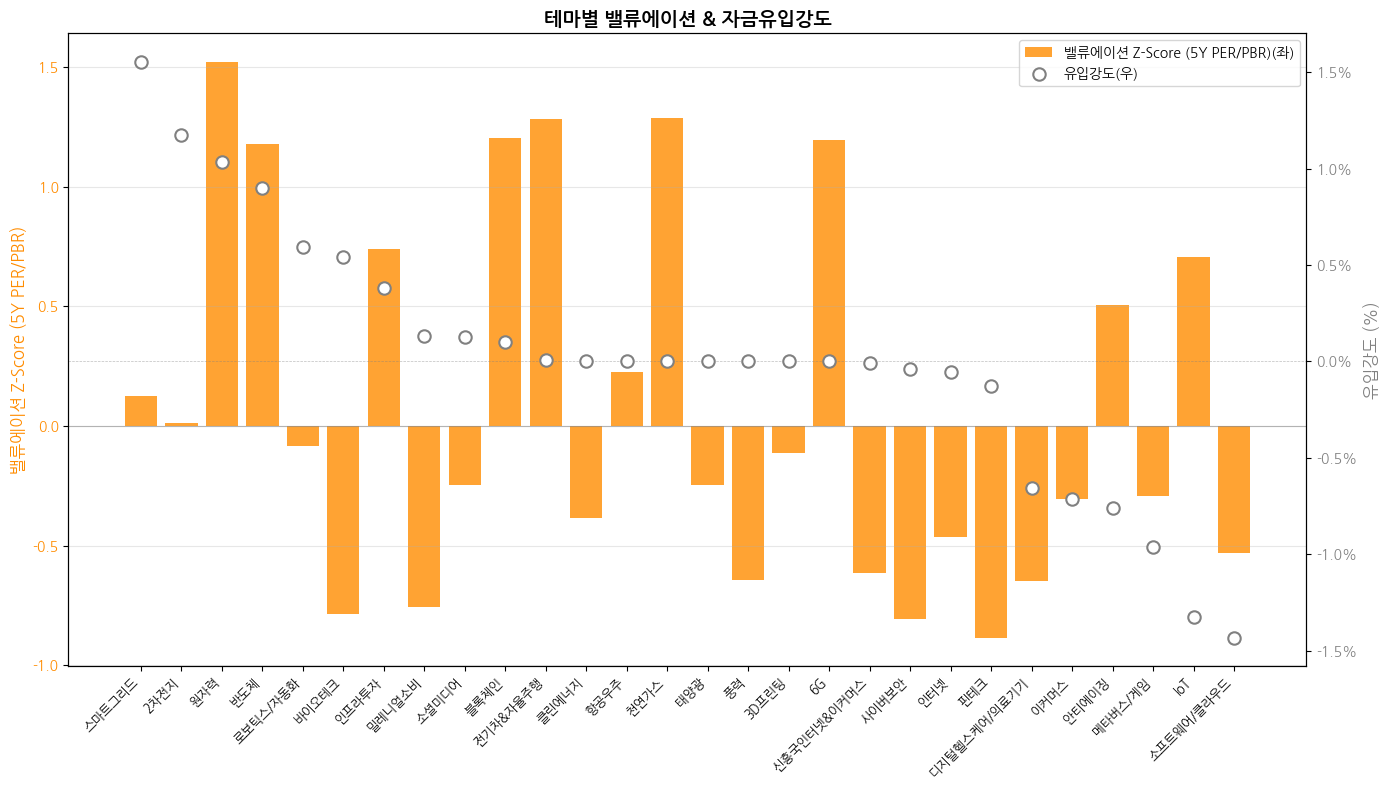

In [ ]:
def create_scatter_chart(df, x_col_now, x_col_1w, y_col_now, y_col_1w,
                         title, xlabel, ylabel, filename, x_is_percent=False):
    """
    스캐터 차트 생성
    - 각 테마마다 현재(점) + 1주전(점) + 화살표 연결
    - 대각선 기준선 (0,0을 지나는 선)
    """
    fig, ax = plt.subplots(figsize=(14, 10))

    # 색상 팔레트
    colors = plt.cm.tab20(np.linspace(0, 1, len(df)))

    # 데이터 범위 계산
    x_all = pd.concat([df[x_col_now], df[x_col_1w]])
    y_all = pd.concat([df[y_col_now], df[y_col_1w]])

    x_min, x_max = x_all.min(), x_all.max()
    y_min, y_max = y_all.min(), y_all.max()

    # 마진 추가
    x_margin = (x_max - x_min) * 0.15
    y_margin = (y_max - y_min) * 0.15

    # 대각선 기준선 (0,0을 지나는 선)
    # 두 축의 스케일을 맞춰서 정규화된 공간에서 45도 선
    x_range = x_max - x_min
    y_range = y_max - y_min
    slope = y_range / x_range if x_range != 0 else 1

    line_x = np.array([x_min - x_margin, x_max + x_margin])
    line_y = slope * line_x  # (0,0)을 지나는 선: y = slope * x

    ax.plot(line_x, line_y, 'k--', alpha=0.5, linewidth=1.5, label='기준선')

    # 각 테마 플롯
    for i, (theme, row) in enumerate(df.iterrows()):
        x_now = row[x_col_now]
        x_1w = row[x_col_1w]
        y_now = row[y_col_now]
        y_1w = row[y_col_1w]

        color = colors[i]

        # 1주전 위치 (작은 점, 연한 색)
        ax.scatter(x_1w, y_1w, c=[color], s=50, alpha=0.2, marker='o')

        # 현재 위치 (큰 점)
        ax.scatter(x_now, y_now, c=[color], s=120, alpha=1.0, marker='o', edgecolors='black', linewidths=0.5)

        # 화살표 (1주전 -> 현재)
        ax.annotate('', xy=(x_now, y_now), xytext=(x_1w, y_1w),
                    arrowprops=dict(arrowstyle='->', color=color, alpha=0.2, lw=1.5))

        # 라벨 (현재 위치에 테마명 표시)
        ax.annotate(theme, (x_now, y_now), fontsize=8, alpha=0.9, fontweight='bold',
                    # xytext=(8, 8), textcoords='offset points')
                    xytext=(0, 12), textcoords='offset points', verticalalignment='bottom', horizontalalignment='center') # 상단
                    # xytext=(0, -12), textcoords='offset points', verticalalignment='top', horizontalalignment='center')

    # 축 설정
    ax.set_xlim(x_min - x_margin, x_max + x_margin)
    ax.set_ylim(y_min - y_margin, y_max + y_margin)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')

    # X축 % 포맷
    if x_is_percent:
        from matplotlib.ticker import FuncFormatter
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.2f}%'))

    # 그리드
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.8, alpha=0.5)

    # 범례 (영역 설명)
    ax.text(0.02, 0.98, '고멀티플, 약모멘텀',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3))
    ax.text(0.98, 0.02, '저멀티플, 강모멘텀',
            transform=ax.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

    plt.tight_layout()

    # 파일 저장
    plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"차트 저장: {filename}")

    return fig


def create_flow_bar_chart(df, wf_col, flow_col, title, filename):
    """
    차트 3: 테마별 순유입금액 (바) + 유입강도 (점)
    - X축: 테마
    - Y축 왼쪽: 순유입금액 ($M) - 바차트
    - Y축 오른쪽: 유입강도 (%) - 점
    """
    from matplotlib.ticker import FuncFormatter

    # # 순유입금액 기준 내림차순 정렬
    # df_sorted = df.sort_values(wf_col, ascending=False)
    # 유입강도 기준 내림차순 정렬
    df_sorted = df.sort_values(flow_col, ascending=False)

    fig, ax1 = plt.subplots(figsize=(14, 8))

    # X축 위치
    x = np.arange(len(df_sorted))
    themes = df_sorted.index.tolist()

    # 왼쪽 Y축: 순유입금액 (바차트)
    bars = ax1.bar(x, df_sorted[wf_col], color='darkorange', alpha=0.8, label='밸류에이션 Z-Score (5Y PER/PBR)(좌)')
    ax1.set_ylabel('밸류에이션 Z-Score (5Y PER/PBR)', fontsize=12, color='darkorange')
    ax1.tick_params(axis='y', labelcolor='darkorange')
    ax1.axhline(y=0, color='gray', linewidth=0.8, alpha=0.5)

    # 오른쪽 Y축: 유입강도 (점)
    ax2 = ax1.twinx()
    ax2.scatter(x, df_sorted[flow_col], color='white', edgecolors='gray',
                s=80, linewidths=1.5, zorder=5, label='유입강도(우)')
    ax2.set_ylabel('유입강도 (%)', fontsize=12, color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, p: f'{y:.1f}%'))
    ax2.axhline(y=0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)

    # X축 설정
    ax1.set_xticks(x)
    ax1.set_xticklabels(themes, rotation=45, ha='right', fontsize=9)
    ax1.set_xlabel('')

    # 제목
    ax1.set_title(title, fontsize=14, fontweight='bold')

    # 범례
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    # 그리드
    ax1.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"차트 저장: {filename}")

    return fig


# 차트 1: 멀티플 Z-Score vs 모멘텀 스코어
fig1 = create_scatter_chart(
    df_chart1,
    x_col_now='Momentum_Now', x_col_1w='Momentum_1W',
    y_col_now='ZScore_Now', y_col_1w='ZScore_1W',
    title='테마별 밸류에이션 vs 모멘텀 (주간 변화)',
    xlabel='모멘텀 스코어',
    ylabel='밸류에이션 Z-Score (5Y PER/PBR)',
    filename='chart1_valuation_momentum.png'
)
plt.show()

# # 차트 2: 멀티플 Z-Score vs 자금유입강도
# fig2 = create_scatter_chart(
#     df_chart2,
#     x_col_now='Flow_Now', x_col_1w='Flow_1W',
#     y_col_now='ZScore_Now', y_col_1w='ZScore_1W',
#     title='테마별 밸류에이션 vs 자금유입강도 (주간 변화)',
#     xlabel='자금유입강도 (%)',
#     ylabel='밸류에이션 Z-Score (5Y PER/PBR)',
#     filename='chart2_valuation_flow.png',
#     x_is_percent=True
# )
# plt.show()

# 차트 3: 테마별 순유입금액 & 유입강도
fig3 = create_flow_bar_chart(
    df_chart3,
    wf_col='ZScore_Now',
    flow_col='flow_4w',
    title='테마별 밸류에이션 & 자금유입강도',
    filename='chart3_flow_bar.png'
)
plt.show()

## 7. 텔레그램 전송

In [ ]:
class TelegramSender:
    def __init__(self, bot_token, chat_id):
        self.bot_token = bot_token
        self.chat_id = chat_id
        self.base_url = f"https://api.telegram.org/bot{bot_token}"

    def send_photo(self, photo_path, caption=None):
        """이미지 파일 전송"""
        url = f"{self.base_url}/sendPhoto"

        with open(photo_path, 'rb') as photo:
            files = {'photo': photo}
            data = {'chat_id': self.chat_id}
            if caption:
                data['caption'] = caption

            response = requests.post(url, files=files, data=data)

        if response.status_code == 200:
            return True
        else:
            print(f"Error: {response.text}")
            return False

# 텔레그램 전송 실행
if BOT_TOKEN and CHAT_ID:
    print("텔레그램 전송 중...")
    sender = TelegramSender(BOT_TOKEN, CHAT_ID)

    from datetime import datetime
    date_str = datetime.now().strftime('%Y-%m-%d')

    # 차트 1 전송
    if sender.send_photo('chart1_valuation_momentum.png',
                         caption=f"테마별 밸류에이션 vs 모멘텀 ({date_str})\n"):
                                #  f"- 좌상단: 고멀티플 + 약모멘텀\n"
                                #  f"- 우하단: 저멀티플 + 강모멘텀"):
        print("차트1 전송 완료")
    else:
        print("차트1 전송 실패")

    # 차트 3 전송
    if sender.send_photo('chart3_flow_bar.png',
                         caption=f"테마별 밸류에이션 및 주간 유입강도(순유입액/AUM) ({date_str})"):
        print("차트3 전송 완료")
    else:
        print("차트3 전송 실패")

    print("\n텔레그램 전송 완료!")
else:
    print("텔레그램 설정이 필요합니다.")

텔레그램 전송 중...
차트1 전송 완료
차트3 전송 완료

텔레그램 전송 완료!


## 8. 데이터 확인 (선택사항)

In [ ]:
# 전체 테마 데이터 확인
print("=== 테마별 Z-Score 및 지표 ===")
display_df = df_theme.copy()
display_df = display_df.round(3)
display_df = display_df.sort_values('ZScore_Now', ascending=False)
display(display_df)

=== 테마별 Z-Score 및 지표 ===


,ZScore_Now,ZScore_1W,Momentum_Now,Momentum_1W,Flow_Now,Flow_1W,WF_Sum,ETF_Count
Theme,,,,,,,,
원자력,1.522,1.564,0.480,0.854,1.033,0.670,9.842316e+07,2
천연가스,1.290,1.268,0.849,0.980,0.000,0.000,0.000000e+00,1
전기차&자율주행,1.284,1.509,1.121,1.234,0.008,0.223,4.260709e+04,2
블록체인,1.205,1.279,0.074,0.511,0.099,0.269,1.563242e+06,2
6G,1.195,1.258,0.945,1.364,0.000,0.000,0.000000e+00,2
반도체,1.180,1.276,1.138,1.481,0.898,0.308,4.841788e+08,2
인프라투자,0.742,0.752,0.752,0.853,0.379,0.197,7.117926e+07,2
IoT,0.706,0.641,-0.006,0.229,-1.328,-0.907,-2.723912e+06,1
안티에이징,0.508,0.460,1.585,1.324,-0.760,3.290,-1.577823e+07,3


In [ ]:
# 주요 테마 위치 변화 요약
# print("=== 주간 변화 요약 ===")
df_summary = df_theme.copy()
df_summary['ZScore_Change'] = df_summary['ZScore_Now'] - df_summary['ZScore_1W']
df_summary['Momentum_Change'] = df_summary['Momentum_Now'] - df_summary['Momentum_1W']
df_summary['Flow_Change'] = df_summary['Flow_Now'] - df_summary['Flow_1W']

# # Z-Score 상승 Top 5
# print("\n[Z-Score 상승 Top 5 (밸류에이션 부담 증가)]")
# print(df_summary.nlargest(5, 'ZScore_Change')[['ZScore_Now', 'ZScore_1W', 'ZScore_Change']].round(3))

# # Z-Score 하락 Top 5
# print("\n[Z-Score 하락 Top 5 (밸류에이션 매력 증가)]")
# print(df_summary.nsmallest(5, 'ZScore_Change')[['ZScore_Now', 'ZScore_1W', 'ZScore_Change']].round(3))

# # 모멘텀 상승 Top 5
# print("\n[모멘텀 상승 Top 5]")
# print(df_summary.nlargest(5, 'Momentum_Change')[['Momentum_Now', 'Momentum_1W', 'Momentum_Change']].round(3))

# # 자금유입 상승 Top 5
# print("\n[자금유입 상승 Top 5]")
# print(df_summary.nlargest(5, 'Flow_Change')[['Flow_Now', 'Flow_1W', 'Flow_Change']].round(3))

In [ ]:

# ============================================================
# 주간 변화 요약 테이블 이미지 생성 및 텔레그램 전송
# ============================================================


def get_display_width(text):
    """문자열의 표시 너비 계산 (한글=2, 영문/숫자=1)"""
    width = 0
    for char in str(text):
        # 한글, 한자, 일본어 등 동아시아 문자는 2칸
        if '\uac00' <= char <= '\ud7af' or '\u4e00' <= char <= '\u9fff' or '\u3040' <= char <= '\u30ff':
            width += 2
        else:
            width += 1
    return width

def pad_to_width(text, target_width, align='left'):
    """목표 너비에 맞춰 공백 패딩 (한글 너비 고려)"""
    current_width = get_display_width(text)
    padding = target_width - current_width
    if padding < 0:
        padding = 0
    if align == 'left':
        return str(text) + ' ' * padding
    else:  # right
        return ' ' * padding + str(text)

def create_summary_html(df_summary):
    """모바일 가독성 좋은 고정폭 텍스트 생성 (한글 너비 보정)"""
    from datetime import datetime
    date_str = datetime.now().strftime('%Y-%m-%d')

    # 컬럼 너비 설정
    COL_GAP = 3  # 컬럼 간 간격

    # 각 섹션별 테마명 최대 너비 계산
    def get_max_theme_width(df_subset):
        return max(get_display_width(idx) for idx in df_subset.index)

    lines = []
    lines.append(f"<b>★ 테마별 주간 변화 요약 ({date_str}) ★</b>")
    lines.append("")

    # # 1. Z-Score 상승 (고평가)
    # section_data = df_summary.nlargest(5, 'ZScore_Change')
    # theme_w = max(get_max_theme_width(section_data), get_display_width("테마"))
    # val_w = 6  # +0.52 형태
    # chg_w = 8  # ▲+0.284 형태

    # header = pad_to_width("테마", theme_w + COL_GAP) + pad_to_width("현재", val_w + COL_GAP) + pad_to_width("1주전", val_w + COL_GAP) + "변화"
    # sep_line = "-" * get_display_width(header)

    # lines.append("<b>1. 멀티플 Z-Score Top5</b>")
    # lines.append(sep_line)
    # lines.append(header)
    # lines.append(sep_line)
    # for idx, row in section_data.iterrows():
    #     change = row['ZScore_Change']
    #     arrow = "▲" if change > 0 else "▼"
    #     col1 = pad_to_width(idx, theme_w + COL_GAP)
    #     col2 = pad_to_width(f"{row['ZScore_Now']:+.2f}", val_w + COL_GAP)
    #     col3 = pad_to_width(f"{row['ZScore_1W']:+.2f}", val_w + COL_GAP)
    #     col4 = f"{arrow}{change:+.2f}"
    #     lines.append(col1 + col2 + col3 + col4)
    # lines.append("")

    # # 2. Z-Score 하락 (저평가)
    # section_data = df_summary.nsmallest(5, 'ZScore_Change')
    # theme_w = max(get_max_theme_width(section_data), get_display_width("테마"))

    # header = pad_to_width("테마", theme_w + COL_GAP) + pad_to_width("현재", val_w + COL_GAP) + pad_to_width("1주전", val_w + COL_GAP) + "변화"
    # sep_line = "-" * get_display_width(header)

    # lines.append("<b>2. [Z-Score 하락] 역사적 평균 대비 저평가</b>")
    # lines.append(sep_line)
    # lines.append(header)
    # lines.append(sep_line)
    # for idx, row in section_data.iterrows():
    #     change = row['ZScore_Change']
    #     arrow = "▲" if change > 0 else "▼"
    #     col1 = pad_to_width(idx, theme_w + COL_GAP)
    #     col2 = pad_to_width(f"{row['ZScore_Now']:+.1f}", val_w + COL_GAP)
    #     col3 = pad_to_width(f"{row['ZScore_1W']:+.1f}", val_w + COL_GAP)
    #     col4 = f"{arrow}{change:+.3f}"
    #     lines.append(col1 + col2 + col3 + col4)
    # lines.append("")

    # 3. 모멘텀 상승
    section_data = df_summary.nlargest(5, 'Momentum_Change')
    theme_w = max(get_max_theme_width(section_data), get_display_width("테마"))
    val_w = 6  # +0.52 형태
    chg_w = 8  # ▲+0.284 형태

    header = pad_to_width("테마", theme_w + COL_GAP) + pad_to_width("현재", val_w + COL_GAP) + pad_to_width("1주전", val_w + COL_GAP) + "변화"
    sep_line = "-" * get_display_width(header)

    lines.append("<b>1. 모멘텀 증가 Top 5</b>")
    lines.append(sep_line)
    lines.append(header)
    lines.append(sep_line)
    for idx, row in section_data.iterrows():
        change = row['Momentum_Change']
        arrow = "▲" if change > 0 else "▼"
        col1 = pad_to_width(idx, theme_w + COL_GAP)
        col2 = pad_to_width(f"{row['Momentum_Now']:.2f}", val_w + COL_GAP)
        col3 = pad_to_width(f"{row['Momentum_1W']:.2f}", val_w + COL_GAP)
        col4 = f"{arrow}{change:+.2f}"
        lines.append(col1 + col2 + col3 + col4)
    lines.append("")

    # 2. 모멘텀 감소
    section_data = df_summary.nsmallest(5, 'Momentum_Change')
    theme_w = max(get_max_theme_width(section_data), get_display_width("테마"))

    header = pad_to_width("테마", theme_w + COL_GAP) + pad_to_width("현재", val_w + COL_GAP) + pad_to_width("1주전", val_w + COL_GAP) + "변화"
    sep_line = "-" * get_display_width(header)

    lines.append("<b>2. 모멘텀 감소 Top 5</b>")
    lines.append(sep_line)
    lines.append(header)
    lines.append(sep_line)
    for idx, row in section_data.iterrows():
        change = row['Momentum_Change']
        arrow = "▲" if change > 0 else "▼"
        col1 = pad_to_width(idx, theme_w + COL_GAP)
        col2 = pad_to_width(f"{row['Momentum_Now']:.2f}", val_w + COL_GAP)
        col3 = pad_to_width(f"{row['Momentum_1W']:.2f}", val_w + COL_GAP)
        col4 = f"{arrow}{change:+.2f}"
        lines.append(col1 + col2 + col3 + col4)
    lines.append("")

    # 4. 자금유입 상대강도
    section_data = df_summary.nlargest(3, 'Flow_Change')
    theme_w = max(get_max_theme_width(section_data), get_display_width("테마"))
    flow_w = 7  # +0.52% 형태

    header = pad_to_width("테마", theme_w + COL_GAP) + pad_to_width("현재", flow_w + COL_GAP) + pad_to_width("1주전", flow_w + COL_GAP) + "변화"
    sep_line = "-" * get_display_width(header)

    lines.append("<b>3. 주간 자금 유입 상대강도 Top 3</b>")
    lines.append(sep_line)
    lines.append(header)
    lines.append(sep_line)
    for idx, row in section_data.iterrows():
        change = row['Flow_Change']
        arrow = "▲" if change > 0 else "▼"
        col1 = pad_to_width(idx, theme_w + COL_GAP)
        col2 = pad_to_width(f"{row['Flow_Now']:+.2f}%", flow_w + COL_GAP)
        col3 = pad_to_width(f"{row['Flow_1W']:+.2f}%", flow_w + COL_GAP)
        col4 = f"{arrow}{change:+.2f}%p"
        lines.append(col1 + col2 + col3 + col4)
    lines.append("")

    # 4. 자금유입 상대강도
    section_data = df_summary.nsmallest(3, 'Flow_Change')
    theme_w = max(get_max_theme_width(section_data), get_display_width("테마"))
    flow_w = 7  # +0.52% 형태

    header = pad_to_width("테마", theme_w + COL_GAP) + pad_to_width("현재", flow_w + COL_GAP) + pad_to_width("1주전", flow_w + COL_GAP) + "변화"
    sep_line = "-" * get_display_width(header)

    lines.append("<b>4. 주간 자금 유출 상대강도 Top 3</b>")
    lines.append(sep_line)
    lines.append(header)
    lines.append(sep_line)
    for idx, row in section_data.iterrows():
        change = row['Flow_Change']
        arrow = "▲" if change > 0 else "▼"
        col1 = pad_to_width(idx, theme_w + COL_GAP)
        col2 = pad_to_width(f"{row['Flow_Now']:+.2f}%", flow_w + COL_GAP)
        col3 = pad_to_width(f"{row['Flow_1W']:+.2f}%", flow_w + COL_GAP)
        col4 = f"{arrow}{change:+.2f}%p"
        lines.append(col1 + col2 + col3 + col4)

    return "\n".join(lines)


# 요약 테이블 이미지 생성

df_summary = df_theme.copy()
df_summary['ZScore_Change'] = df_summary['ZScore_Now'] - df_summary['ZScore_1W']
df_summary['Momentum_Change'] = df_summary['Momentum_Now'] - df_summary['Momentum_1W']
df_summary['Flow_Change'] = df_summary['Flow_Now'] - df_summary['Flow_1W']


# HTML 버전 출력
print("\n" + "=" * 50)
print("텍스트 버전 (모바일용)")
print("=" * 50)
summary_text = create_summary_html(df_summary)
print(summary_text)


텍스트 버전 (모바일용)
<b>★ 테마별 주간 변화 요약 (2025-12-17) ★</b>

<b>1. 모멘텀 증가 Top 5</b>
------------------------------------------------
테마                      현재     1주전    변화
------------------------------------------------
안티에이징                1.58     1.32     ▲+0.26
2차전지                   1.98     1.76     ▲+0.22
바이오테크                2.00     1.89     ▲+0.12
풍력                      1.24     1.18     ▲+0.06
디지털헬스케어/의료기기   0.94     0.88     ▲+0.05

<b>2. 모멘텀 감소 Top 5</b>
-----------------------------------
테마         현재     1주전    변화
-----------------------------------
블록체인     0.07     0.51     ▼-0.44
6G           0.94     1.36     ▼-0.42
사이버보안   -0.26    0.16     ▼-0.41
원자력       0.48     0.85     ▼-0.37
반도체       1.14     1.48     ▼-0.34

<b>3. 주간 자금 유입 상대강도 Top 3</b>
-------------------------------------
테마         현재      1주전     변화
-------------------------------------
바이오테크   +0.54%    -2.79%    ▲+3.34%p
항공우주     +0.00%    -1.65%    ▲+1.65%p
2차전지      +1.18%    +0.01%    ▲+1.16%p

<b>4.

In [ ]:
# 텔레그램 전송
if BOT_TOKEN and CHAT_ID:
    print("\n" + "=" * 50)
    print("텔레그램 전송")
    print("=" * 50)
    sender = TelegramSender(BOT_TOKEN, CHAT_ID)

    from datetime import datetime
    date_str = datetime.now().strftime('%Y-%m-%d')

    # # 이미지 전송
    # if sender.send_photo('weekly_summary.png', caption=f"테마별 주간 변화 요약 ({date_str})"):
    #     print("이미지 전송 완료!")
    # else:
    #     print("이미지 전송 실패")

    # 텍스트 전송 (HTML 모드)
    url = f"https://api.telegram.org/bot{BOT_TOKEN}/sendMessage"
    data = {
        'chat_id': CHAT_ID,
        'text': f"{summary_text}",
        'parse_mode': 'HTML'
    }
    response = requests.post(url, data=data)
    if response.status_code == 200:
        print("텍스트 전송 완료!")
    else:
        print(f"텍스트 전송 실패: {response.text}")
else:
    print("텔레그램 설정이 필요합니다.")


텔레그램 전송
텍스트 전송 완료!


데이터 다운로드 중... (13개 ETF)


[*********************100%***********************]  13 of 13 completed


다운로드 완료: 3772일 x 13종목
차트 저장 완료: dispersion_chart.png


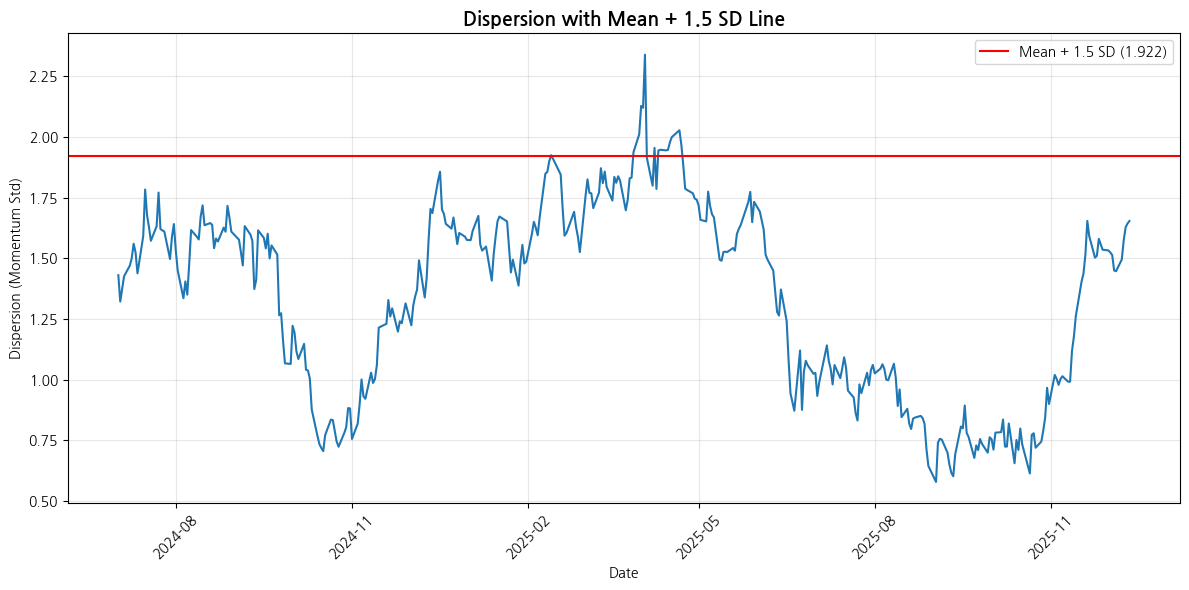

In [ ]:
# ============================================================
# 테마 모멘텀 Dispersion 차트 생성 및 텔레그램 전송
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests
import os

# ===== 사용자 설정 영역 =====
# 아래 universe_tickers를 원하는 ETF 목록으로 변경하세요
universe_tickers = ['LIT', 'SMH','SIXG','CIBR','ESPO','AIQ','GRID','FCOM','XBI', 'SHLD','BLOK', 'KWEB','AIRR']
# universe_tickers = ['LIT', 'SMH','SIXG','CIBR','ESPO','AIQ','GRID','FCOM','XBI', 'SHLD','BLOK', '0047A0.KS','AIRR']
# ============================

# 데이터 다운로드
end_date = datetime.now().strftime("%Y-%m-%d")
start_date = pd.to_datetime(end_date) - pd.DateOffset(years=15)

print(f"데이터 다운로드 중... ({len(universe_tickers)}개 ETF)")
data = yf.download(universe_tickers, start=start_date, end=end_date, auto_adjust=False)['Adj Close']
data.ffill(inplace=True)
print(f"다운로드 완료: {data.shape[0]}일 x {data.shape[1]}종목")

# 모멘텀 계산
prices = data
momentum50 = prices.pct_change().rolling(50).mean() / prices.pct_change().rolling(200).std(ddof=0) * np.sqrt(252)
momentum50.dropna(inplace=True)

momentum100 = prices.pct_change().rolling(100).mean() / prices.pct_change().rolling(200).std(ddof=0) * np.sqrt(252)
momentum100.dropna(inplace=True)

momentum200 = prices.pct_change().rolling(200).mean() / prices.pct_change().rolling(200).std(ddof=0) * np.sqrt(252)
momentum200.dropna(inplace=True)

momentum = np.clip(momentum50, -3, 3)*2 + np.clip(momentum100, -3, 3)* np.sqrt(2) + np.clip(momentum200, -3, 3)
momentum = momentum/3

# Dispersion 계산
dispersion = momentum.std(axis=1)

# 차트 생성 및 저장
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(dispersion.index, dispersion.values, linewidth=1.5)
ax.axhline(y=dispersion.mean() + 1.5*dispersion.std(), color='r', linestyle='-', label=f'Mean + 1.5 SD ({dispersion.mean() + 1.5*dispersion.std():.3f})')
ax.set_title("Dispersion with Mean + 1.5 SD Line", fontsize=14, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Dispersion (Momentum Std)")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

# 이미지 저장
chart_filename = 'dispersion_chart.png'
plt.savefig(chart_filename, dpi=150, bbox_inches='tight', facecolor='white')
print(f"차트 저장 완료: {chart_filename}")
plt.show()

In [ ]:
# 텔레그램 전송
BOT_TOKEN = os.environ.get('TELEGRAM_BOT_TOKEN', "8328122559:AAEXkzJnxtljMON_Obt4uyb5PzJvx5-IS64")
CHAT_ID = os.environ.get('TELEGRAM_CHAT_ID', "7481149685")

if BOT_TOKEN and CHAT_ID:
    print("\n텔레그램 전송 중...")

    date_str = datetime.now().strftime('%Y-%m-%d')

    caption = f"""테마 모멘텀 Dispersion ({date_str})
[{', '.join(universe_tickers)}]

* 자산간 모멘텀 표준편차가 높을수록(dispersed days) 테마간 성과 차이가 큼 → 테마간 적극적 비중 전략 필요
* 자산간 모멘텀 표준편차가 낮을수록(macro days) 테마간 성과 차이가 작음 → 포트 전체의 현금비중을 조절"""

    url = f"https://api.telegram.org/bot{BOT_TOKEN}/sendPhoto"

    with open(chart_filename, 'rb') as photo:
        files = {'photo': photo}
        data_req = {'chat_id': CHAT_ID, 'caption': caption}
        response = requests.post(url, files=files, data=data_req)

    if response.status_code == 200:
        print("텔레그램 전송 완료!")
    else:
        print(f"텔레그램 전송 실패: {response.text}")
else:
    print("텔레그램 설정이 필요합니다.")


텔레그램 전송 중...
텔레그램 전송 완료!
